# Microsoft Planetary Computer Met Office check

In [1]:
import duckdb

con = duckdb.connect()
con.sql("DESCRIBE SELECT * FROM 'output/checks.parquet'")

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ collection         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ item               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ reference_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ has_item           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ num_missing        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [2]:
con.sql("DESCRIBE SELECT * FROM 'output/paths.parquet'")

┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ model              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ reference_datetime │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ path               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ collection         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ item               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [3]:
monthly = con.sql("""
    SELECT
        date_trunc('month', reference_datetime) AS month,
        SUM(CASE WHEN NOT has_item THEN 1 ELSE 0 END) AS missing,
        SUM(CASE WHEN has_item AND num_missing > 0 THEN 1 ELSE 0 END) AS incomplete,
        SUM(CASE WHEN has_item AND num_missing = 0 THEN 1 ELSE 0 END) AS complete
    FROM 'output/checks.parquet'
    GROUP BY month
    ORDER BY month
""").df().set_index("month")
monthly

,missing,incomplete,complete
month,,,
2024-05-01,6098.0,607.0,1197.0
2024-06-01,3144.0,5659.0,17837.0
2024-07-01,24.0,7586.0,19918.0
2024-08-01,17.0,6298.0,21213.0
2024-09-01,15.0,6034.0,20591.0
2024-10-01,16.0,6921.0,20591.0
2024-11-01,2398.0,8314.0,22758.0
2024-12-01,3184.0,6306.0,27214.0
2025-01-01,3321.0,8852.0,24531.0


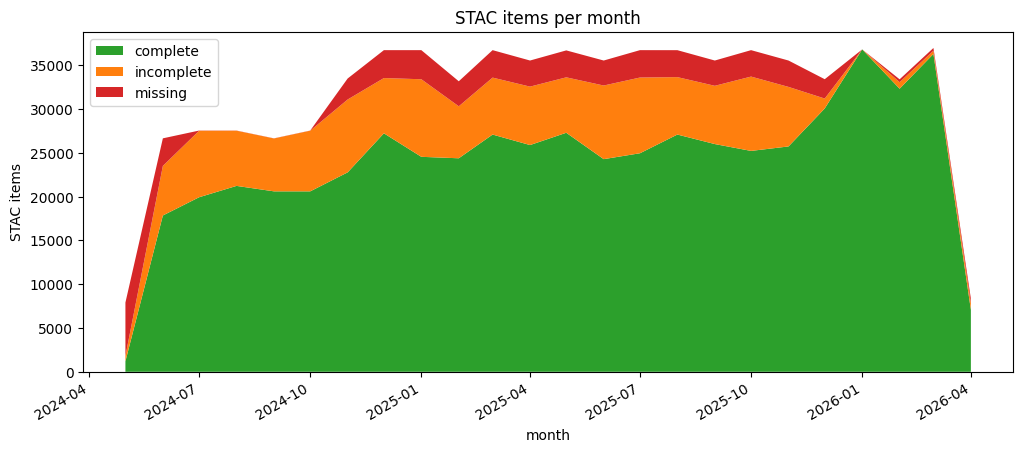

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    monthly.index,
    monthly["complete"],
    monthly["incomplete"],
    monthly["missing"],
    labels=["complete", "incomplete", "missing"],
    colors=["#2ca02c", "#ff7f0e", "#d62728"],
)
ax.set_xlabel("month")
ax.set_ylabel("STAC items")
ax.set_title("STAC items per month")
ax.legend(loc="upper left")
fig.autofmt_xdate()
plt.show()